In [16]:
# ============================================================
# CELL 1: INSTALL REQUIRED LIBRARIES
# ============================================================

!pip -q install kagglehub scikit-image seaborn

print("Libraries installed successfully.")

Libraries installed successfully.


In [17]:
# ============================================================
# CELL 2: DOWNLOAD DATASET DIRECTLY FROM KAGGLE
# ============================================================

import os
import kagglehub

DATASET_PATH = kagglehub.dataset_download(
    "nodoubttome/skin-cancer9-classesisic"
)

print("Dataset downloaded successfully!")
print("Dataset path:")
print(DATASET_PATH)

print("\nFiles/folders inside dataset:")
for item in os.listdir(DATASET_PATH):
    print(" -", item)

Dataset downloaded successfully!
Dataset path:
/root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1

Files/folders inside dataset:
 - Skin cancer ISIC The International Skin Imaging Collaboration


In [18]:
# ============================================================
# CELL 3: IMPORT LIBRARIES
# ============================================================

import os
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from skimage.filters import prewitt
from skimage.transform import resize

import cv2

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

ImageFile.LOAD_TRUNCATED_IMAGES = True

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [19]:
# ============================================================
# CELL 4: FIND ALL IMAGE FILES AND THEIR CLASS FOLDERS
# ============================================================

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

all_image_records = []

for root, dirs, files in os.walk(DATASET_PATH):

    for file_name in files:

        if file_name.lower().endswith(IMAGE_EXTENSIONS):

            full_path = os.path.join(root, file_name)

            # The immediate parent folder is treated as the class
            class_name = os.path.basename(root)

            all_image_records.append({
                "filepath": full_path,
                "class": class_name
            })

df_all = pd.DataFrame(all_image_records)

print("Total images found:", len(df_all))

if len(df_all) == 0:
    raise RuntimeError(
        "No images were found. Check the Kaggle download and dataset path."
    )

print("\nAll detected classes:")
print(sorted(df_all["class"].unique()))

print("\nImages per detected class:")
print(df_all["class"].value_counts())

Total images found: 2357

All detected classes:
['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']

Images per detected class:
class
pigmented benign keratosis    478
melanoma                      454
basal cell carcinoma          392
nevus                         373
squamous cell carcinoma       197
vascular lesion               142
actinic keratosis             130
dermatofibroma                111
seborrheic keratosis           80
Name: count, dtype: int64


In [20]:
# ============================================================
# CELL 5: SELECT EXACTLY 6 CLASSES
# ============================================================

def normalize_class_name(name):
    """
    Converts class names into a comparable format.
    Example:
    'Basal Cell Carcinoma' -> 'basal cell carcinoma'
    """
    return (
        str(name)
        .strip()
        .lower()
        .replace("_", " ")
        .replace("-", " ")
    )


df_all["normalized_class"] = df_all["class"].apply(normalize_class_name)

TARGET_CLASSES = [
    "actinic keratosis",
    "basal cell carcinoma",
    "dermatofibroma",
    "melanoma",
    "nevus",
    "pigmented benign keratosis"
]

available_normalized = set(df_all["normalized_class"].unique())

missing_classes = [
    cls for cls in TARGET_CLASSES
    if cls not in available_normalized
]

if missing_classes:
    print("WARNING: These requested classes were not found:")
    for cls in missing_classes:
        print(" -", cls)

    print("\nAvailable classes:")
    for cls in sorted(available_normalized):
        print(" -", cls)

    raise ValueError(
        "One or more required classes were not found. "
        "Check the printed class names."
    )

df = df_all[
    df_all["normalized_class"].isin(TARGET_CLASSES)
].copy()

# Keep clean class names
df["class"] = df["normalized_class"]

df = df.drop(columns=["normalized_class"])

print("Selected classes:")
print(sorted(df["class"].unique()))

print("\nTotal images in selected 6 classes:", len(df))

print("\nClass distribution:")
print(df["class"].value_counts())

Selected classes:
['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis']

Total images in selected 6 classes: 1938

Class distribution:
class
pigmented benign keratosis    478
melanoma                      454
basal cell carcinoma          392
nevus                         373
actinic keratosis             130
dermatofibroma                111
Name: count, dtype: int64


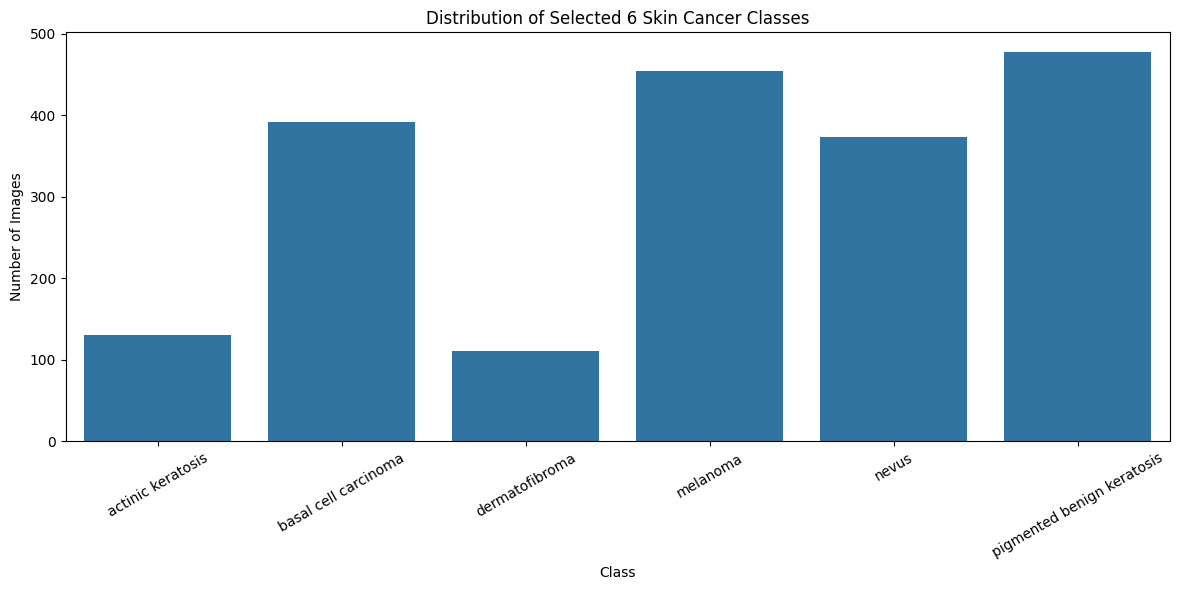

In [21]:
# ============================================================
# CELL 6: CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="class",
    order=TARGET_CLASSES
)

plt.title("Distribution of Selected 6 Skin Cancer Classes")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# CELL 7: CREATE NUMERICAL LABELS
# ============================================================

class_names = TARGET_CLASSES

class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

index_to_class = {
    index: class_name
    for class_name, index in class_to_index.items()
}

df["label"] = df["class"].map(class_to_index)

print("Class mapping:")

for index, class_name in index_to_class.items():
    print(index, "=", class_name)

print("\nLabel distribution:")
print(df["label"].value_counts().sort_index())

Class mapping:
0 = actinic keratosis
1 = basal cell carcinoma
2 = dermatofibroma
3 = melanoma
4 = nevus
5 = pigmented benign keratosis

Label distribution:
label
0    130
1    392
2    111
3    454
4    373
5    478
Name: count, dtype: int64


In [23]:
# ============================================================
# CELL 8: TRAIN / VALIDATION / TEST SPLIT
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))

print("\nTraining distribution:")
print(train_df["class"].value_counts())

print("\nValidation distribution:")
print(val_df["class"].value_counts())

print("\nTesting distribution:")
print(test_df["class"].value_counts())

Training images: 1356
Validation images: 291
Testing images: 291

Training distribution:
class
pigmented benign keratosis    334
melanoma                      318
basal cell carcinoma          274
nevus                         261
actinic keratosis              91
dermatofibroma                 78
Name: count, dtype: int64

Validation distribution:
class
pigmented benign keratosis    72
melanoma                      68
basal cell carcinoma          59
nevus                         56
actinic keratosis             19
dermatofibroma                17
Name: count, dtype: int64

Testing distribution:
class
pigmented benign keratosis    72
melanoma                      68
basal cell carcinoma          59
nevus                         56
actinic keratosis             20
dermatofibroma                16
Name: count, dtype: int64


Image shape: (160, 160, 3)


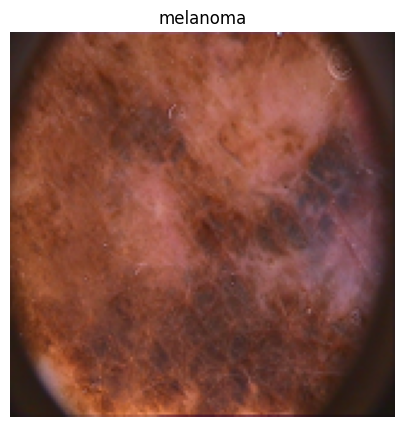

In [24]:
# ============================================================
# CELL 9: IMAGE LOADING FUNCTION
# ============================================================

IMG_SIZE = 160

def load_image(image_path, size=IMG_SIZE):
    """
    Loads an image and converts it to RGB.
    """

    image = Image.open(image_path).convert("RGB")
    image = image.resize((size, size))

    return np.array(image)


sample_path = train_df.iloc[0]["filepath"]

sample_image = load_image(sample_path)

print("Image shape:", sample_image.shape)

plt.figure(figsize=(5, 5))
plt.imshow(sample_image)
plt.title(train_df.iloc[0]["class"])
plt.axis("off")
plt.show()

In [25]:
# ============================================================
# CELL 10: EDGE DETECTION FUNCTIONS
# ============================================================

def to_gray(image):
    """
    Convert RGB image to grayscale.
    """

    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image

    return gray


def sobel_gx(image):
    gray = to_gray(image)

    gx = cv2.Sobel(
        gray,
        cv2.CV_64F,
        1,
        0,
        ksize=3
    )

    gx = np.abs(gx)
    gx = cv2.normalize(
        gx,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    return gx


def sobel_gy(image):
    gray = to_gray(image)

    gy = cv2.Sobel(
        gray,
        cv2.CV_64F,
        0,
        1,
        ksize=3
    )

    gy = np.abs(gy)
    gy = cv2.normalize(
        gy,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    return gy


def sobel_magnitude(image):
    gray = to_gray(image)

    gx = cv2.Sobel(
        gray,
        cv2.CV_64F,
        1,
        0,
        ksize=3
    )

    gy = cv2.Sobel(
        gray,
        cv2.CV_64F,
        0,
        1,
        ksize=3
    )

    magnitude = np.sqrt(
        gx ** 2 + gy ** 2
    )

    magnitude = cv2.normalize(
        magnitude,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    return magnitude


def prewitt_edge(image):
    gray = to_gray(image)

    result = prewitt(
        gray.astype(np.float32) / 255.0
    )

    result = (
        result * 255
    ).clip(0, 255).astype(np.uint8)

    return result


def laplacian_edge(image):
    gray = to_gray(image)

    result = cv2.Laplacian(
        gray,
        cv2.CV_64F
    )

    result = np.abs(result)

    result = cv2.normalize(
        result,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    return result


def log_edge(image):
    gray = to_gray(image)

    # Gaussian smoothing
    blurred = cv2.GaussianBlur(
        gray,
        (5, 5),
        0
    )

    # Laplacian after Gaussian
    result = cv2.Laplacian(
        blurred,
        cv2.CV_64F
    )

    result = np.abs(result)

    result = cv2.normalize(
        result,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    return result


def canny_edge(
    image,
    low_threshold=50,
    high_threshold=150,
    kernel_size=3
):

    gray = to_gray(image)

    # Canny internally performs smoothing,
    # but we explicitly smooth here for control.
    blurred = cv2.GaussianBlur(
        gray,
        (kernel_size, kernel_size),
        0
    )

    edges = cv2.Canny(
        blurred,
        low_threshold,
        high_threshold
    )

    return edges


print("All edge detection functions created successfully.")

All edge detection functions created successfully.


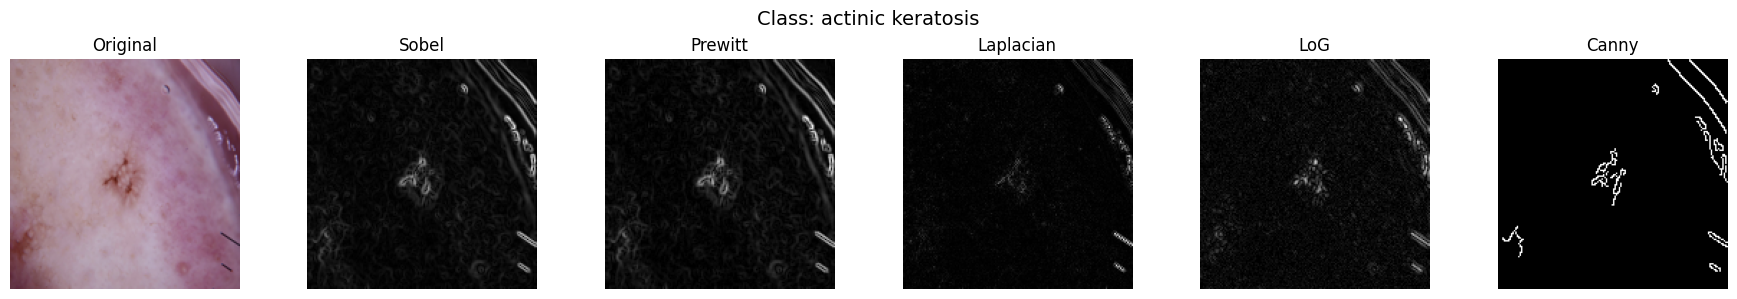

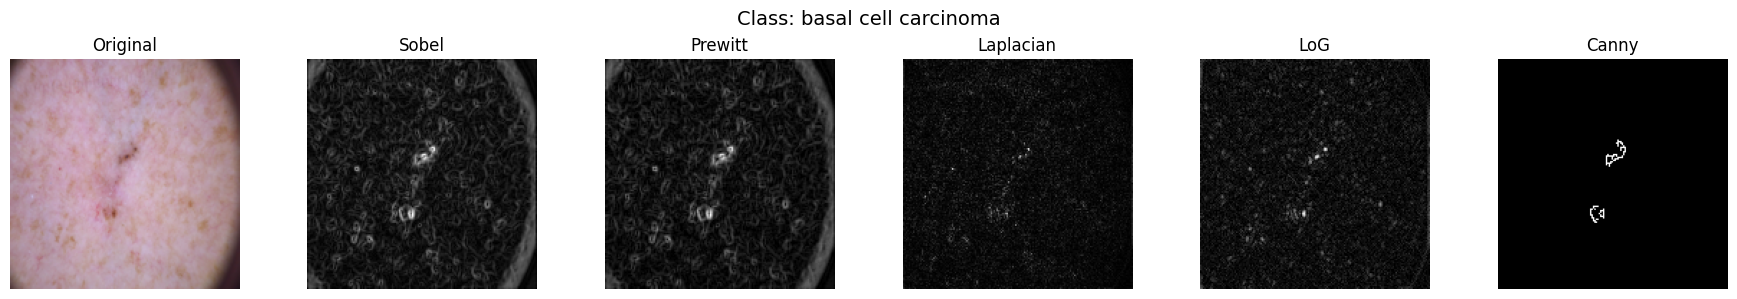

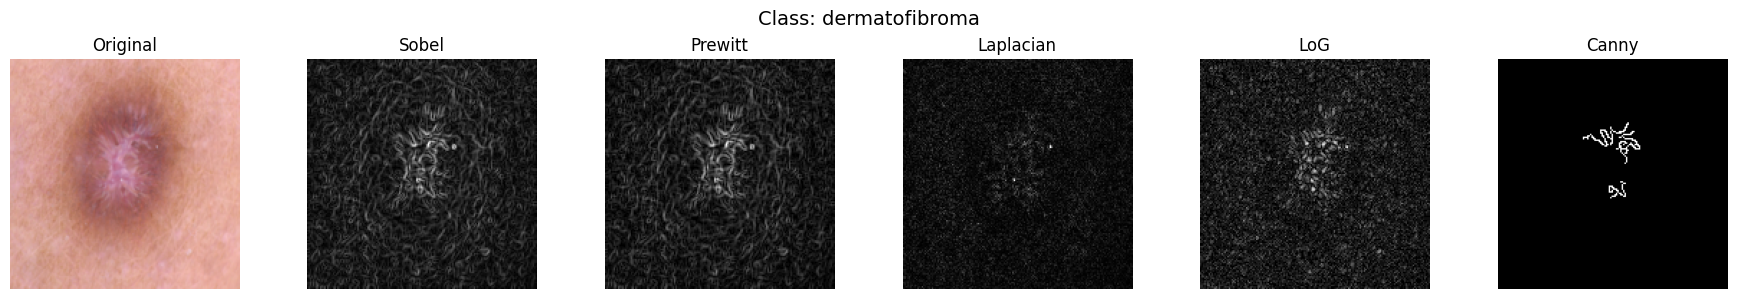

In [26]:
# ============================================================
# CELL 11: TASK 1 - COMPARATIVE EDGE DETECTION
# ============================================================

representative_images = []

for class_name in class_names[:3]:

    class_data = df[
        df["class"] == class_name
    ]

    if len(class_data) > 0:
        representative_images.append(
            class_data.iloc[0]
        )


for row in representative_images:

    image = load_image(row["filepath"])

    sobel = sobel_magnitude(image)
    prewitt_img = prewitt_edge(image)
    laplacian = laplacian_edge(image)
    log_img = log_edge(image)
    canny = canny_edge(image, 50, 150, 3)

    plt.figure(figsize=(18, 3))

    images = [
        image,
        sobel,
        prewitt_img,
        laplacian,
        log_img,
        canny
    ]

    titles = [
        "Original",
        "Sobel",
        "Prewitt",
        "Laplacian",
        "LoG",
        "Canny"
    ]

    for i in range(len(images)):

        plt.subplot(1, 6, i + 1)

        if i == 0:
            plt.imshow(images[i])
        else:
            plt.imshow(images[i], cmap="gray")

        plt.title(titles[i])
        plt.axis("off")

    plt.suptitle(
        "Class: " + row["class"],
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

In [27]:
# ============================================================
# CELL 12: NOISE FUNCTIONS
# ============================================================

def add_gaussian_noise(
    image,
    mean=0,
    sigma=20
):

    image_float = image.astype(np.float32)

    noise = np.random.normal(
        mean,
        sigma,
        image.shape
    )

    noisy = image_float + noise

    noisy = np.clip(
        noisy,
        0,
        255
    ).astype(np.uint8)

    return noisy


def add_salt_pepper_noise(
    image,
    amount=0.03,
    salt_vs_pepper=0.5
):

    noisy = image.copy()

    total_pixels = image.shape[0] * image.shape[1]

    num_salt = int(
        total_pixels * amount * salt_vs_pepper
    )

    num_pepper = int(
        total_pixels * amount * (1 - salt_vs_pepper)
    )

    # Salt
    rows = np.random.randint(
        0,
        image.shape[0],
        num_salt
    )

    cols = np.random.randint(
        0,
        image.shape[1],
        num_salt
    )

    noisy[rows, cols] = 255

    # Pepper
    rows = np.random.randint(
        0,
        image.shape[0],
        num_pepper
    )

    cols = np.random.randint(
        0,
        image.shape[1],
        num_pepper
    )

    noisy[rows, cols] = 0

    return noisy


def gaussian_filter(image):

    return cv2.GaussianBlur(
        image,
        (5, 5),
        0
    )


def median_filter(image):

    return cv2.medianBlur(
        image,
        5
    )


print("Noise and filtering functions created.")

Noise and filtering functions created.


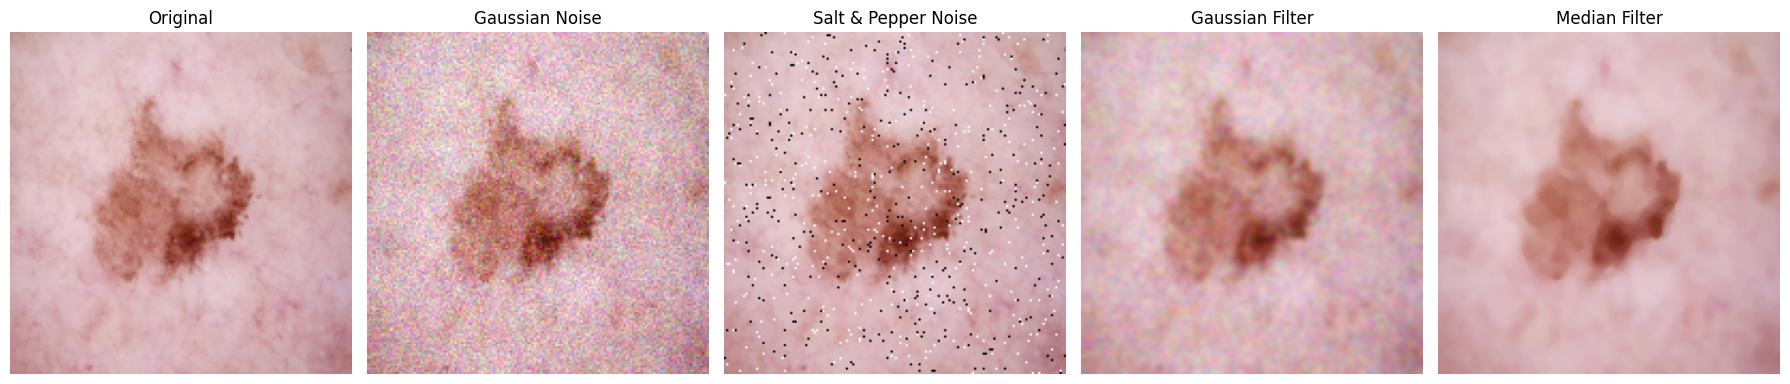

In [28]:
# ============================================================
# CELL 13: NOISE + FILTERING VISUALIZATION
# ============================================================

row = df.iloc[0]

original = load_image(row["filepath"])

gaussian_noisy = add_gaussian_noise(
    original,
    sigma=20
)

salt_pepper_noisy = add_salt_pepper_noise(
    original,
    amount=0.03
)

gaussian_filtered = gaussian_filter(
    gaussian_noisy
)

median_filtered = median_filter(
    salt_pepper_noisy
)

images = [
    original,
    gaussian_noisy,
    salt_pepper_noisy,
    gaussian_filtered,
    median_filtered
]

titles = [
    "Original",
    "Gaussian Noise",
    "Salt & Pepper Noise",
    "Gaussian Filter",
    "Median Filter"
]

plt.figure(figsize=(18, 4))

for i in range(len(images)):

    plt.subplot(1, 5, i + 1)

    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

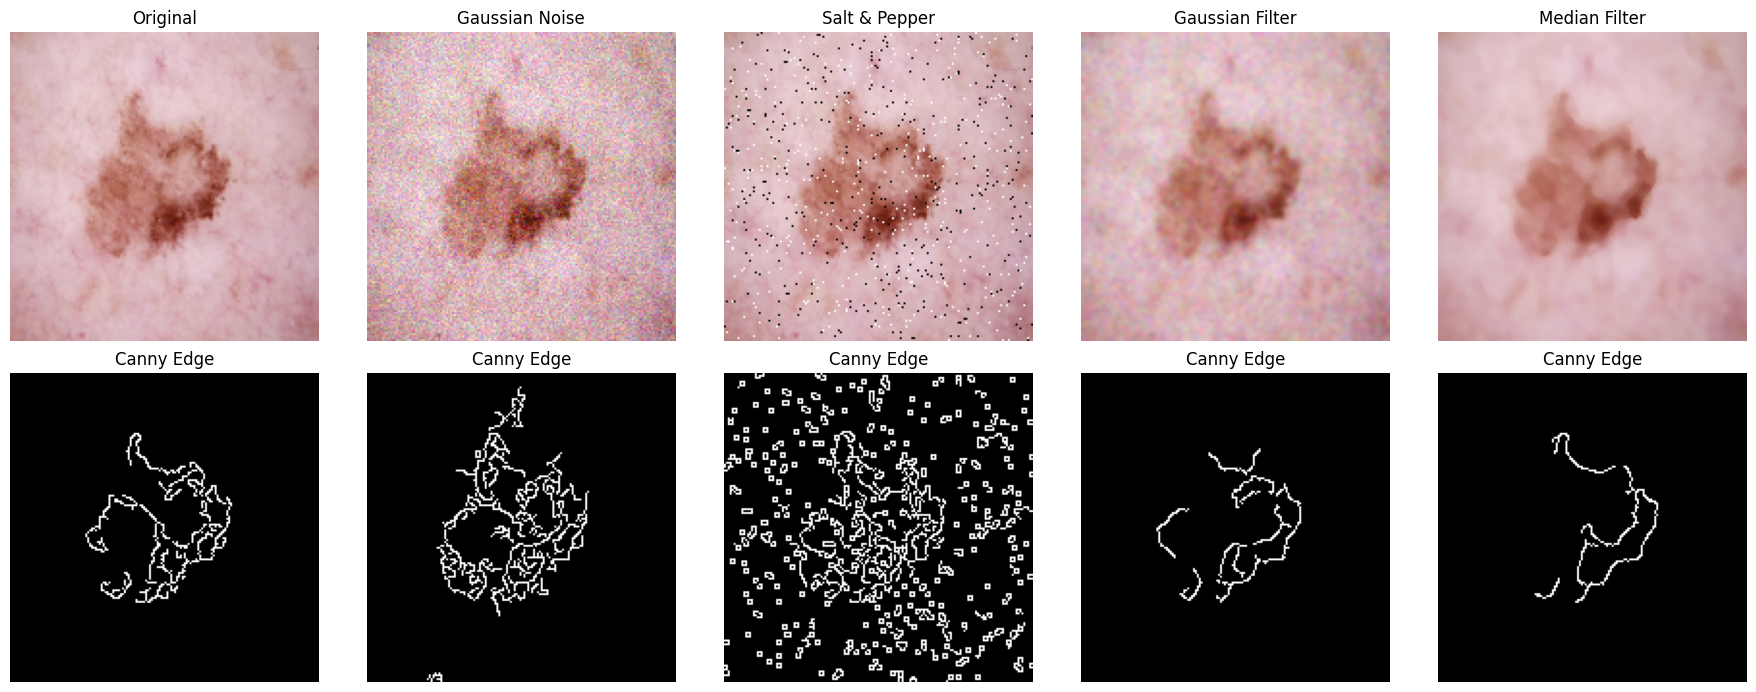

In [29]:
# ============================================================
# CELL 14: EFFECT OF NOISE AND FILTERING ON EDGES
# ============================================================

images = [
    original,
    gaussian_noisy,
    salt_pepper_noisy,
    gaussian_filtered,
    median_filtered
]

titles = [
    "Original",
    "Gaussian Noise",
    "Salt & Pepper",
    "Gaussian Filter",
    "Median Filter"
]

plt.figure(figsize=(18, 7))

for i, img in enumerate(images):

    edges = canny_edge(
        img,
        low_threshold=50,
        high_threshold=150,
        kernel_size=3
    )

    plt.subplot(2, 5, i + 1)

    plt.imshow(img)
    plt.title(titles[i])
    plt.axis("off")

    plt.subplot(2, 5, i + 6)

    plt.imshow(edges, cmap="gray")
    plt.title("Canny Edge")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# CELL 15: CANNY PARAMETER ANALYSIS
# ============================================================

canny_configs = [
    ("Canny-1", 30, 100, 3),
    ("Canny-2", 50, 150, 3),
    ("Canny-3", 100, 200, 3),
    ("Canny-4", 50, 150, 5)
]

canny_results = []

gray_original = to_gray(original)

for name, low, high, kernel in canny_configs:

    edges = canny_edge(
        original,
        low,
        high,
        kernel
    )

    edge_count = np.count_nonzero(edges)

    edge_percentage = (
        edge_count /
        edges.size
    ) * 100

    canny_results.append({
        "Configuration": name,
        "Low Threshold": low,
        "High Threshold": high,
        "Kernel Size": f"{kernel}x{kernel}",
        "Detected Edge Pixels": edge_count,
        "Edge Percentage": edge_percentage
    })


canny_table = pd.DataFrame(
    canny_results
)

display(canny_table)

,Configuration,Low Threshold,High Threshold,Kernel Size,Detected Edge Pixels,Edge Percentage
0,Canny-1,30,100,3x3,1310,5.117188
1,Canny-2,50,150,3x3,675,2.636719
2,Canny-3,100,200,3x3,197,0.769531
3,Canny-4,50,150,5x5,506,1.976562


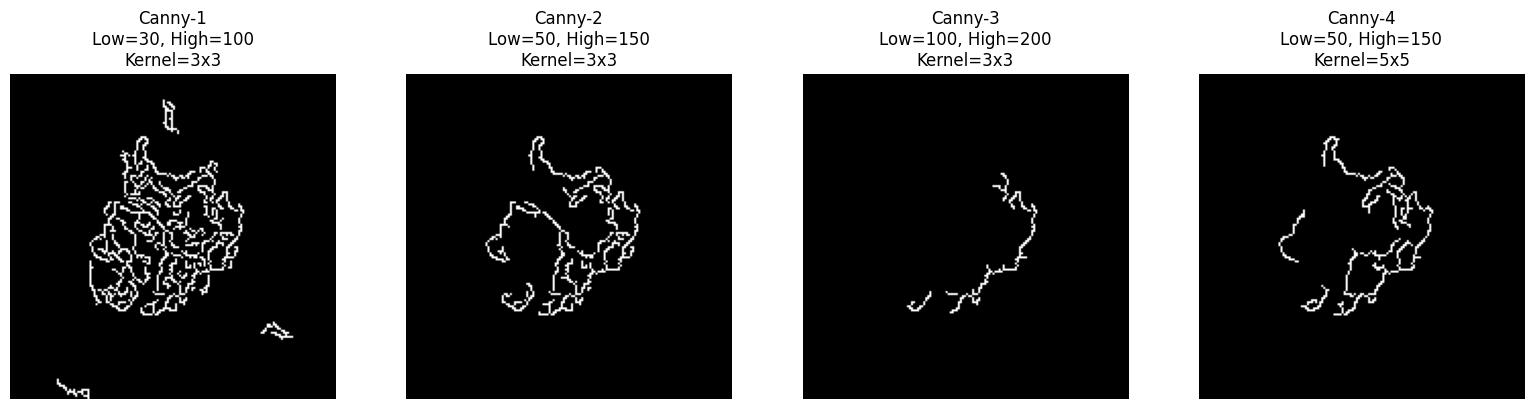

In [31]:
# ============================================================
# CELL 16: DISPLAY CANNY CONFIGURATIONS
# ============================================================

plt.figure(figsize=(16, 4))

for i, (name, low, high, kernel) in enumerate(canny_configs):

    edges = canny_edge(
        original,
        low,
        high,
        kernel
    )

    plt.subplot(1, 4, i + 1)

    plt.imshow(
        edges,
        cmap="gray"
    )

    plt.title(
        f"{name}\n"
        f"Low={low}, High={high}\n"
        f"Kernel={kernel}x{kernel}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# CELL 17: CANNY CONFIGURATION SUMMARY
# ============================================================

print("Canny Parameter Analysis")
print("=" * 60)

for _, row in canny_table.iterrows():

    print(
        f"{row['Configuration']}: "
        f"Low={row['Low Threshold']}, "
        f"High={row['High Threshold']}, "
        f"Kernel={row['Kernel Size']}, "
        f"Edges={row['Detected Edge Pixels']}, "
        f"Edge %={row['Edge Percentage']:.2f}%"
    )

Canny Parameter Analysis
Canny-1: Low=30, High=100, Kernel=3x3, Edges=1310, Edge %=5.12%
Canny-2: Low=50, High=150, Kernel=3x3, Edges=675, Edge %=2.64%
Canny-3: Low=100, High=200, Kernel=3x3, Edges=197, Edge %=0.77%
Canny-4: Low=50, High=150, Kernel=5x5, Edges=506, Edge %=1.98%


In [33]:
# ============================================================
# CELL 18: CREATE RAW / FILTERED / EDGE DATA
# ============================================================

def preprocess_image(image_path, mode):

    image = load_image(image_path)

    if mode == "raw":

        result = image

    elif mode == "filtered":

        result = cv2.GaussianBlur(
            image,
            (5, 5),
            0
        )

    elif mode == "edge":

        edges = canny_edge(
            image,
            low_threshold=50,
            high_threshold=150,
            kernel_size=3
        )

        # Convert grayscale edge image to RGB
        result = cv2.cvtColor(
            edges,
            cv2.COLOR_GRAY2RGB
        )

    else:

        raise ValueError(
            "Mode must be raw, filtered, or edge."
        )

    result = result.astype(np.float32) / 255.0

    return result


def create_dataset(dataframe, mode):

    X = []
    y = []

    for _, row in dataframe.iterrows():

        try:

            image = preprocess_image(
                row["filepath"],
                mode
            )

            X.append(image)
            y.append(row["label"])

        except Exception as e:

            print(
                "Skipped image:",
                row["filepath"],
                "| Error:",
                e
            )

    return (
        np.array(X, dtype=np.float32),
        np.array(y, dtype=np.int32)
    )


print("Preparing RAW dataset...")

X_train_raw, y_train = create_dataset(
    train_df,
    "raw"
)

X_val_raw, y_val = create_dataset(
    val_df,
    "raw"
)

X_test_raw, y_test = create_dataset(
    test_df,
    "raw"
)

print("Raw datasets created.")

print("\nPreparing FILTERED dataset...")

X_train_filtered, _ = create_dataset(
    train_df,
    "filtered"
)

X_val_filtered, _ = create_dataset(
    val_df,
    "filtered"
)

X_test_filtered, _ = create_dataset(
    test_df,
    "filtered"
)

print("Filtered datasets created.")

print("\nPreparing EDGE dataset...")

X_train_edge, _ = create_dataset(
    train_df,
    "edge"
)

X_val_edge, _ = create_dataset(
    val_df,
    "edge"
)

X_test_edge, _ = create_dataset(
    test_df,
    "edge"
)

print("Edge datasets created.")

Preparing RAW dataset...
Raw datasets created.

Preparing FILTERED dataset...
Filtered datasets created.

Preparing EDGE dataset...
Edge datasets created.


In [34]:
# ============================================================
# CELL 19: VERIFY DATASETS
# ============================================================

print("RAW")
print("Train:", X_train_raw.shape)
print("Validation:", X_val_raw.shape)
print("Test:", X_test_raw.shape)

print("\nFILTERED")
print("Train:", X_train_filtered.shape)
print("Validation:", X_val_filtered.shape)
print("Test:", X_test_filtered.shape)

print("\nEDGE")
print("Train:", X_train_edge.shape)
print("Validation:", X_val_edge.shape)
print("Test:", X_test_edge.shape)

print("\nLabels:")
print("Train:", y_train.shape)
print("Validation:", y_val.shape)
print("Test:", y_test.shape)

RAW
Train: (1356, 160, 160, 3)
Validation: (291, 160, 160, 3)
Test: (291, 160, 160, 3)

FILTERED
Train: (1356, 160, 160, 3)
Validation: (291, 160, 160, 3)
Test: (291, 160, 160, 3)

EDGE
Train: (1356, 160, 160, 3)
Validation: (291, 160, 160, 3)
Test: (291, 160, 160, 3)

Labels:
Train: (1356,)
Validation: (291,)
Test: (291,)


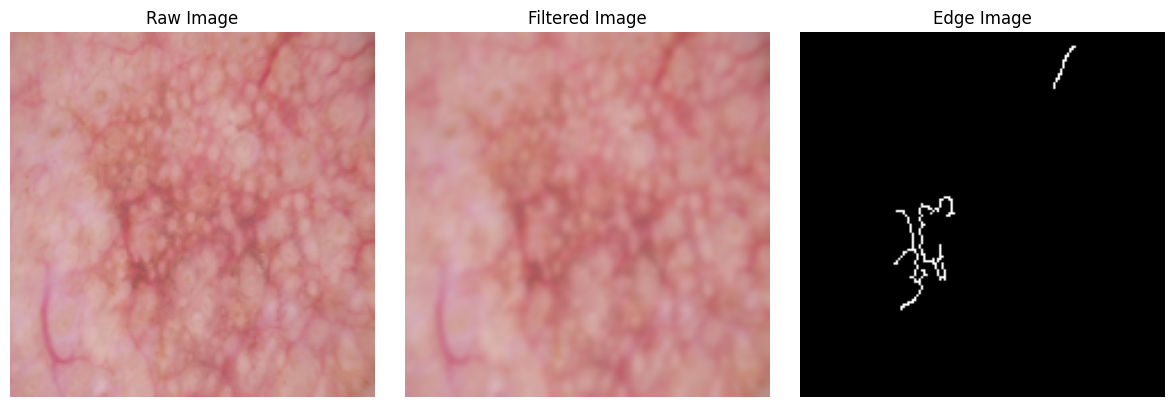

True class: nevus


In [35]:
# ============================================================
# CELL 20: RAW vs FILTERED vs EDGE
# ============================================================

index = 0

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(X_test_raw[index])
plt.title("Raw Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(X_test_filtered[index])
plt.title("Filtered Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(
    X_test_edge[index],
    cmap="gray"
)
plt.title("Edge Image")
plt.axis("off")

plt.tight_layout()
plt.show()

print(
    "True class:",
    index_to_class[y_test[index]]
)

In [36]:
# ============================================================
# CELL 21: CNN MODEL
# ============================================================

NUM_CLASSES = 6


def create_cnn():

    model = models.Sequential([

        layers.Input(
            shape=(IMG_SIZE, IMG_SIZE, 3)
        ),

        layers.Conv2D(
            32,
            (3, 3),
            activation="relu"
        ),

        layers.MaxPooling2D(
            (2, 2)
        ),

        layers.Conv2D(
            64,
            (3, 3),
            activation="relu"
        ),

        layers.MaxPooling2D(
            (2, 2)
        ),

        layers.Conv2D(
            128,
            (3, 3),
            activation="relu"
        ),

        layers.MaxPooling2D(
            (2, 2)
        ),

        layers.Flatten(),

        layers.Dense(
            128,
            activation="relu"
        ),

        layers.Dropout(0.4),

        layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


model_test = create_cnn()

model_test.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,402,566 (20.61 MB)

 Trainable params: 5,402,566 (20.61 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# ============================================================
# CELL 22: TRAINING FUNCTION
# ============================================================

EPOCHS = 10
BATCH_SIZE = 32


def train_model(
    X_train,
    y_train,
    X_val,
    y_val,
    dataset_name
):

    print("\n" + "=" * 70)
    print("TRAINING:", dataset_name)
    print("=" * 70)

    model = create_cnn()

    callbacks = [

        EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6
        )
    ]

    start_time = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(
            X_val,
            y_val
        ),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    training_time = time.time() - start_time

    return model, history, training_time

In [38]:
# ============================================================
# CELL 23: TRAIN RAW MODEL
# ============================================================

raw_model, raw_history, raw_training_time = train_model(
    X_train_raw,
    y_train,
    X_val_raw,
    y_val,
    "RAW IMAGES"
)

print(
    f"Raw training time: "
    f"{raw_training_time:.2f} seconds"
)


TRAINING: RAW IMAGES
Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 14s 161ms/step - accuracy: 0.2662 - loss: 1.6755 - val_accuracy: 0.4708 - val_loss: 1.4159 - learning_rate: 0.0010
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.4322 - loss: 1.4127 - val_accuracy: 0.4467 - val_loss: 1.4511 - learning_rate: 0.0010
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.4285 - loss: 1.4343 - val_accuracy: 0.5155 - val_loss: 1.3502 - learning_rate: 0.0010
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.4528 - loss: 1.3912 - val_accuracy: 0.4948 - val_loss: 1.2635 - learning_rate: 0.0010
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5103 - loss: 1.2752 - val_accuracy: 0.4845 - val_loss: 1.2832 - learning_rate: 0.0010
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5450 - loss: 1.2157 - val_accuracy: 0.5601 - val_loss: 1.1923 - learning_rate: 0.0010
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.5339 

In [39]:
# ============================================================
# CELL 24: TRAIN FILTERED MODEL
# ============================================================

filtered_model, filtered_history, filtered_training_time = train_model(
    X_train_filtered,
    y_train,
    X_val_filtered,
    y_val,
    "FILTERED IMAGES"
)

print(
    f"Filtered training time: "
    f"{filtered_training_time:.2f} seconds"
)


TRAINING: FILTERED IMAGES
Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - accuracy: 0.2581 - loss: 1.7558 - val_accuracy: 0.4089 - val_loss: 1.5801 - learning_rate: 0.0010
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.3805 - loss: 1.5045 - val_accuracy: 0.3230 - val_loss: 1.5507 - learning_rate: 0.0010
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4440 - loss: 1.4097 - val_accuracy: 0.3711 - val_loss: 1.4688 - learning_rate: 0.0010
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.4417 - loss: 1.4228 - val_accuracy: 0.4570 - val_loss: 1.3158 - learning_rate: 0.0010
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.4889 - loss: 1.3239 - val_accuracy: 0.4639 - val_loss: 1.2974 - learning_rate: 0.0010
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5184 - loss: 1.2804 - val_accuracy: 0.4467 - val_loss: 1.3524 - learning_rate: 0.0010
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5

In [40]:
# ============================================================
# CELL 25: TRAIN EDGE MODEL
# ============================================================

edge_model, edge_history, edge_training_time = train_model(
    X_train_edge,
    y_train,
    X_val_edge,
    y_val,
    "EDGE IMAGES"
)

print(
    f"Edge training time: "
    f"{edge_training_time:.2f} seconds"
)


TRAINING: EDGE IMAGES
Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - accuracy: 0.2463 - loss: 1.7261 - val_accuracy: 0.3402 - val_loss: 1.6331 - learning_rate: 0.0010
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.3746 - loss: 1.5713 - val_accuracy: 0.3368 - val_loss: 1.6151 - learning_rate: 0.0010
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.4941 - loss: 1.3052 - val_accuracy: 0.3436 - val_loss: 1.6770 - learning_rate: 0.0010
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6209 - loss: 1.0113 - val_accuracy: 0.3574 - val_loss: 1.9951 - learning_rate: 0.0010
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7522 - loss: 0.6956 - val_accuracy: 0.3711 - val_loss: 2.6861 - learning_rate: 5.0000e-04
Edge training time: 15.56 seconds


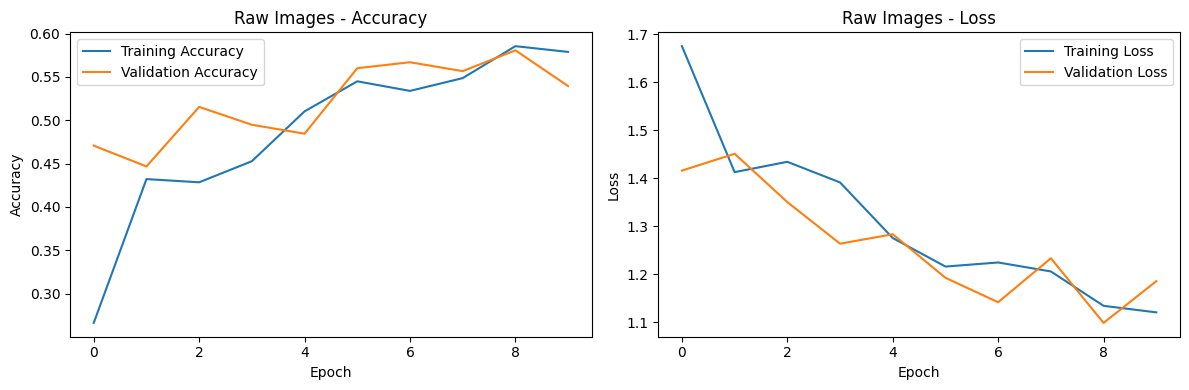

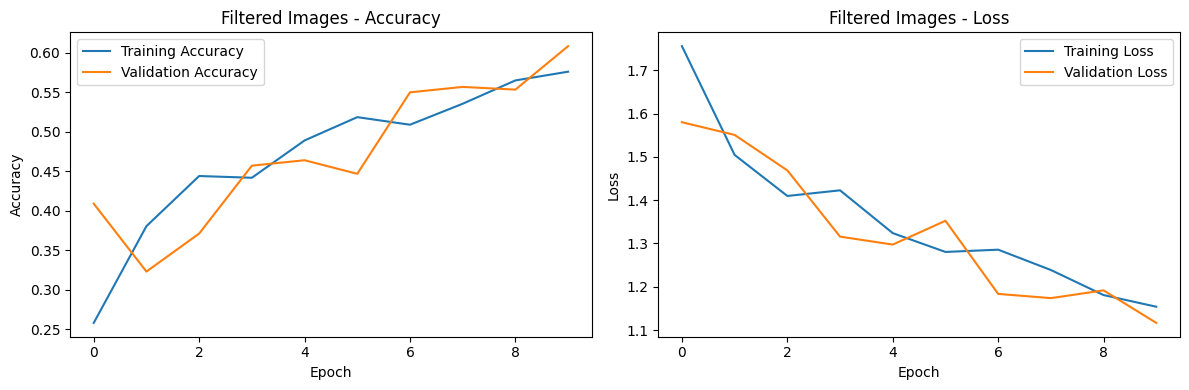

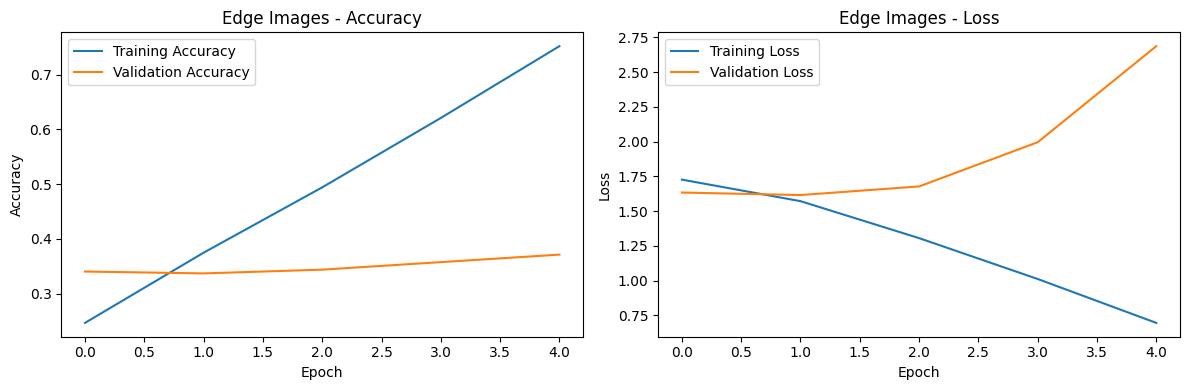

In [41]:
# ============================================================
# CELL 26: TRAINING CURVES
# ============================================================

def plot_history(history, title):

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)

    plt.plot(
        history.history["accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        history.history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.title(
        title + " - Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)

    plt.plot(
        history.history["loss"],
        label="Training Loss"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.title(
        title + " - Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_history(
    raw_history,
    "Raw Images"
)

plot_history(
    filtered_history,
    "Filtered Images"
)

plot_history(
    edge_history,
    "Edge Images"
)

In [42]:
# ============================================================
# CELL 27: MODEL EVALUATION
# ============================================================

def evaluate_model(
    model,
    X_test,
    y_test,
    model_name,
    training_time
):

    # Inference timing
    start_time = time.time()

    probabilities = model.predict(
        X_test,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    total_inference_time = (
        time.time() - start_time
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    inference_time_ms = (
        total_inference_time /
        len(X_test)
    ) * 1000

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    print(
        f"Accuracy : {accuracy:.4f}"
    )

    print(
        f"Precision: {precision:.4f}"
    )

    print(
        f"Recall   : {recall:.4f}"
    )

    print(
        f"F1 Score : {f1:.4f}"
    )

    print(
        f"Training Time: {training_time:.2f} sec"
    )

    print(
        f"Inference Time: {inference_time_ms:.2f} ms/image"
    )

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            predictions,
            target_names=class_names,
            zero_division=0
        )
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Training Time (s)": training_time,
        "Inference Time (ms)": inference_time_ms,
        "Predictions": predictions
    }

In [43]:
# ============================================================
# CELL 29: FILTERED EVALUATION
# ============================================================

filtered_results = evaluate_model(
    filtered_model,
    X_test_filtered,
    y_test,
    "CNN - Filtered",
    filtered_training_time
)


CNN - Filtered
Accuracy : 0.5704
Precision: 0.5179
Recall   : 0.5704
F1 Score : 0.5366
Training Time: 23.90 sec
Inference Time: 9.79 ms/image

Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        20
      basal cell carcinoma       0.53      0.59      0.56        59
            dermatofibroma       0.00      0.00      0.00        16
                  melanoma       0.78      0.66      0.71        68
                     nevus       0.56      0.59      0.57        56
pigmented benign keratosis       0.49      0.74      0.59        72

                  accuracy                           0.57       291
                 macro avg       0.39      0.43      0.41       291
              weighted avg       0.52      0.57      0.54       291



In [44]:
# ============================================================
# CELL 30: EDGE EVALUATION
# ============================================================

edge_results = evaluate_model(
    edge_model,
    X_test_edge,
    y_test,
    "CNN - Edge",
    edge_training_time
)


CNN - Edge
Accuracy : 0.2955
Precision: 0.2591
Recall   : 0.2955
F1 Score : 0.2735
Training Time: 15.56 sec
Inference Time: 7.14 ms/image

Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        20
      basal cell carcinoma       0.26      0.32      0.29        59
            dermatofibroma       0.00      0.00      0.00        16
                  melanoma       0.33      0.40      0.36        68
                     nevus       0.29      0.21      0.24        56
pigmented benign keratosis       0.30      0.39      0.34        72

                  accuracy                           0.30       291
                 macro avg       0.20      0.22      0.21       291
              weighted avg       0.26      0.30      0.27       291



In [46]:
# ============================================================
# CELL 31: TABLE 3 - CLASSIFICATION PERFORMANCE
# ============================================================

# ------------------------------------------------------------
# STEP 1: Check whether evaluation results already exist
# ------------------------------------------------------------

if "raw_results" not in globals():

    print("raw_results not found.")
    print("Evaluating Raw model now...")

    raw_results = evaluate_model(
        raw_model,
        X_test_raw,
        y_test,
        "CNN - Raw",
        raw_training_time
    )


if "filtered_results" not in globals():

    print("\nfiltered_results not found.")
    print("Evaluating Filtered model now...")

    filtered_results = evaluate_model(
        filtered_model,
        X_test_filtered,
        y_test,
        "CNN - Filtered",
        filtered_training_time
    )


if "edge_results" not in globals():

    print("\nedge_results not found.")
    print("Evaluating Edge model now...")

    edge_results = evaluate_model(
        edge_model,
        X_test_edge,
        y_test,
        "CNN - Edge",
        edge_training_time
    )


# ------------------------------------------------------------
# STEP 2: Create Table 3
# ------------------------------------------------------------

results_table = pd.DataFrame([
    {
        "Model": "CNN",

        "Accuracy Raw":
            raw_results["Accuracy"],

        "Accuracy Filtered":
            filtered_results["Accuracy"],

        "Accuracy Edge":
            edge_results["Accuracy"],

        "Precision Raw":
            raw_results["Precision"],

        "Recall Raw":
            raw_results["Recall"],

        "F1 Raw":
            raw_results["F1-Score"],

        "Precision Filtered":
            filtered_results["Precision"],

        "Recall Filtered":
            filtered_results["Recall"],

        "F1 Filtered":
            filtered_results["F1-Score"],

        "Precision Edge":
            edge_results["Precision"],

        "Recall Edge":
            edge_results["Recall"],

        "F1 Edge":
            edge_results["F1-Score"],

        "Training Time Raw (s)":
            raw_results["Training Time (s)"],

        "Training Time Filtered (s)":
            filtered_results["Training Time (s)"],

        "Training Time Edge (s)":
            edge_results["Training Time (s)"],

        "Inference Raw (ms)":
            raw_results["Inference Time (ms)"],

        "Inference Filtered (ms)":
            filtered_results["Inference Time (ms)"],

        "Inference Edge (ms)":
            edge_results["Inference Time (ms)"]
    }
])


print("\n" + "=" * 80)
print("TABLE 3 - CLASSIFICATION PERFORMANCE")
print("=" * 80)

display(
    results_table.round(4)
)

raw_results not found.
Evaluating Raw model now...

CNN - Raw
Accuracy : 0.5395
Precision: 0.5053
Recall   : 0.5395
F1 Score : 0.5137
Training Time: 30.11 sec
Inference Time: 6.60 ms/image

Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        20
      basal cell carcinoma       0.48      0.59      0.53        59
            dermatofibroma       0.00      0.00      0.00        16
                  melanoma       0.81      0.62      0.70        68
                     nevus       0.58      0.62      0.60        56
pigmented benign keratosis       0.43      0.62      0.51        72

                  accuracy                           0.54       291
                 macro avg       0.38      0.41      0.39       291
              weighted avg       0.51      0.54      0.51       291


TABLE 3 - CLASSIFICATION PERFORMANCE


,Model,Accuracy Raw,Accuracy Filtered,Accuracy Edge,Precision Raw,Recall Raw,F1 Raw,Precision Filtered,Recall Filtered,F1 Filtered,Precision Edge,Recall Edge,F1 Edge,Training Time Raw (s),Training Time Filtered (s),Training Time Edge (s),Inference Raw (ms),Inference Filtered (ms),Inference Edge (ms)
0,CNN,0.5395,0.5704,0.2955,0.5053,0.5395,0.5137,0.5179,0.5704,0.5366,0.2591,0.2955,0.2735,30.1075,23.902,15.5631,6.5959,9.7858,7.1412


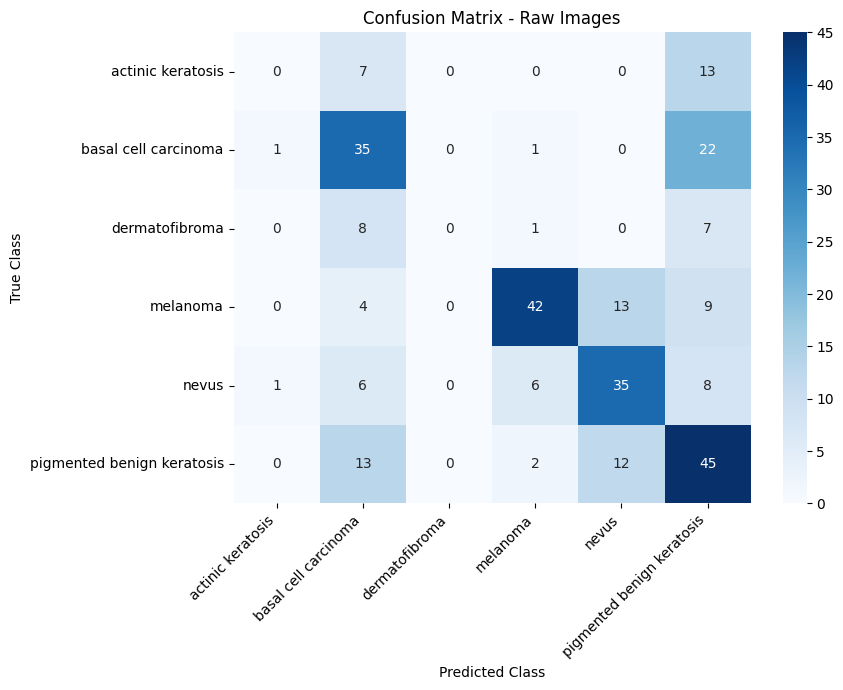

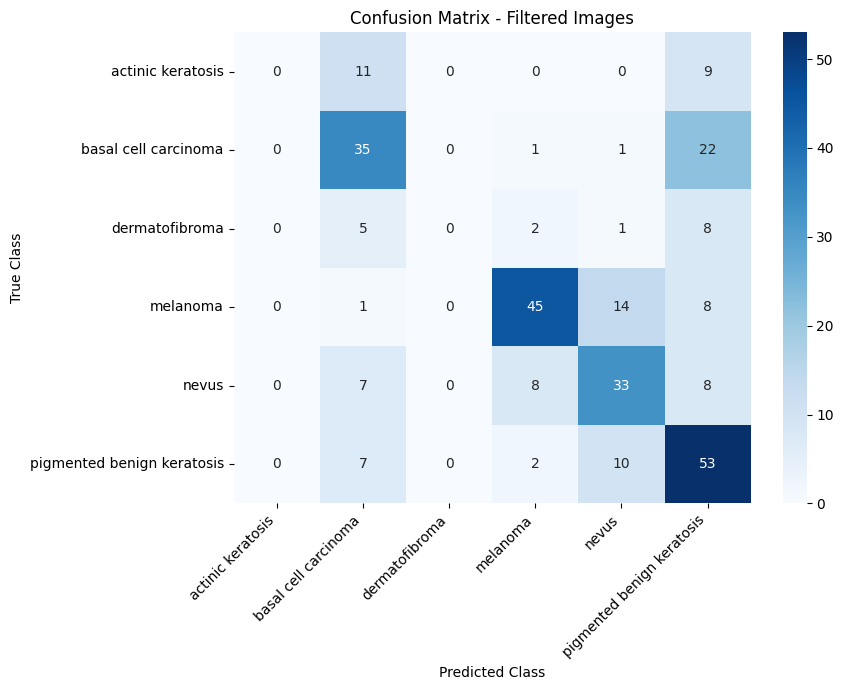

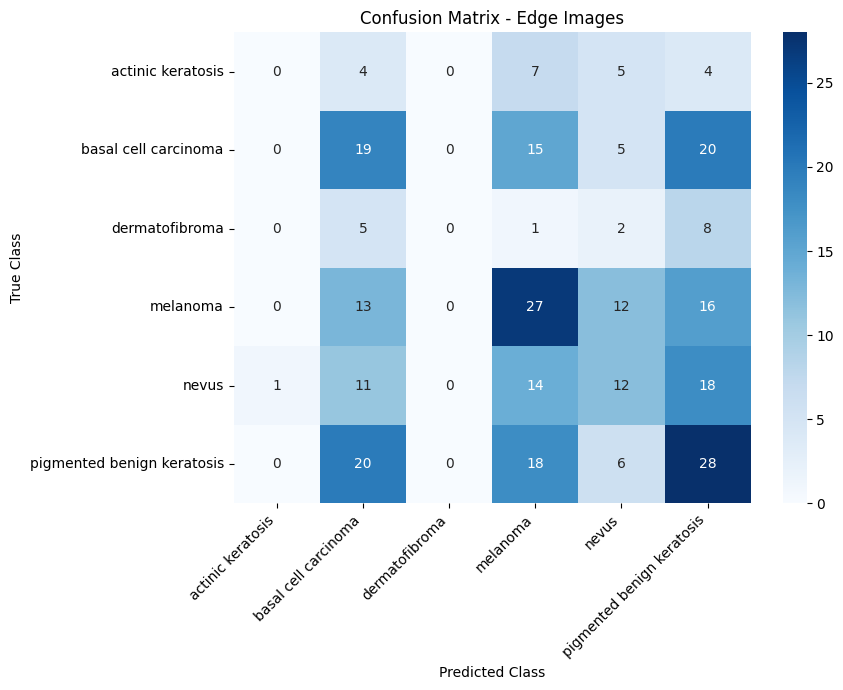

In [47]:
# ============================================================
# CELL 32: CONFUSION MATRICES
# ============================================================

def plot_confusion_matrix(
    y_true,
    y_pred,
    title
):

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(9, 7))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(title)
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.yticks(
        rotation=0
    )

    plt.tight_layout()
    plt.show()


# Raw
plot_confusion_matrix(
    y_test,
    raw_results["Predictions"],
    "Confusion Matrix - Raw Images"
)


# Filtered
plot_confusion_matrix(
    y_test,
    filtered_results["Predictions"],
    "Confusion Matrix - Filtered Images"
)


# Edge
plot_confusion_matrix(
    y_test,
    edge_results["Predictions"],
    "Confusion Matrix - Edge Images"
)

In [48]:
# ============================================================
# CELL 33: PERFORMANCE COMPARISON
# ============================================================

comparison = pd.DataFrame({

    "Representation": [
        "Raw",
        "Filtered",
        "Edge"
    ],

    "Accuracy": [
        raw_results["Accuracy"],
        filtered_results["Accuracy"],
        edge_results["Accuracy"]
    ],

    "Precision": [
        raw_results["Precision"],
        filtered_results["Precision"],
        edge_results["Precision"]
    ],

    "Recall": [
        raw_results["Recall"],
        filtered_results["Recall"],
        edge_results["Recall"]
    ],

    "F1-Score": [
        raw_results["F1-Score"],
        filtered_results["F1-Score"],
        edge_results["F1-Score"]
    ]
})


print("=" * 70)
print("RAW vs FILTERED vs EDGE")
print("=" * 70)

display(
    comparison.round(4)
)

RAW vs FILTERED vs EDGE


,Representation,Accuracy,Precision,Recall,F1-Score
0,Raw,0.5395,0.5053,0.5395,0.5137
1,Filtered,0.5704,0.5179,0.5704,0.5366
2,Edge,0.2955,0.2591,0.2955,0.2735


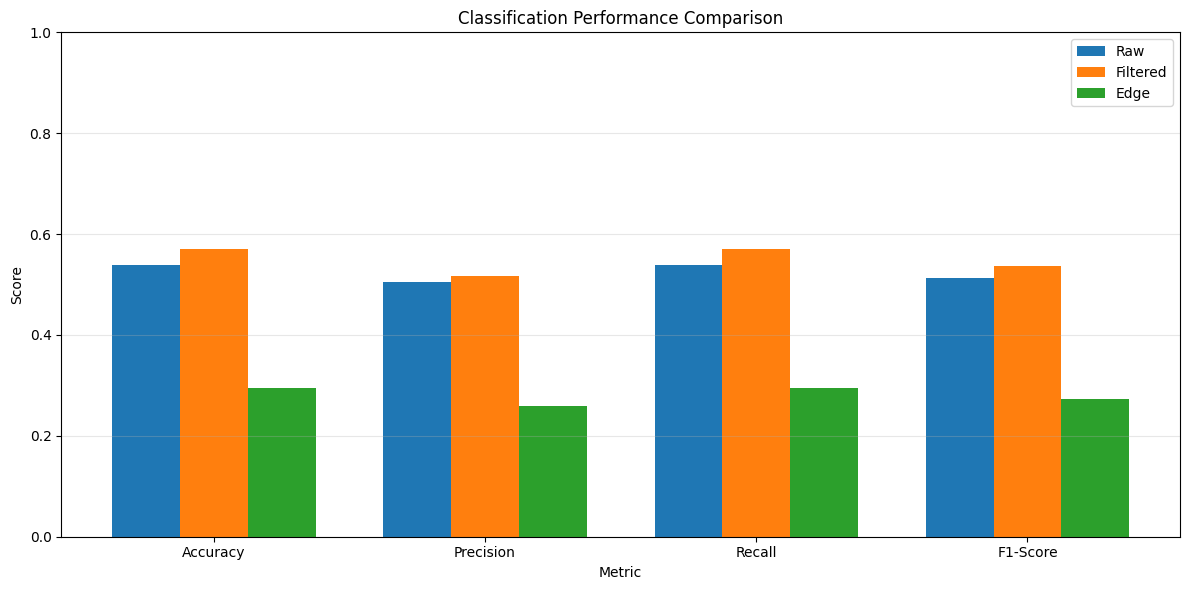

In [49]:
# ============================================================
# CELL 34: PERFORMANCE BAR CHART
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

x = np.arange(len(metrics))

width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    x - width,
    comparison.iloc[0][metrics].astype(float),
    width,
    label="Raw"
)

plt.bar(
    x,
    comparison.iloc[1][metrics].astype(float),
    width,
    label="Filtered"
)

plt.bar(
    x + width,
    comparison.iloc[2][metrics].astype(float),
    width,
    label="Edge"
)

plt.xticks(
    x,
    metrics
)

plt.ylabel("Score")
plt.xlabel("Metric")

plt.title(
    "Classification Performance Comparison"
)

plt.ylim(
    0,
    1
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [51]:
# ============================================================
# CELL 35: TABLE 1 - NOISE AND PREPROCESSING ANALYSIS
# ============================================================

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Define edge detector function here
# ------------------------------------------------------------

def get_edges_for_detector(detector, image, canny_low=50, canny_high=150):
    """
    Apply the requested edge detector to an RGB image.
    Returns a binary edge image.
    """

    # Make sure image is uint8
    image = np.asarray(image)

    if image.dtype != np.uint8:
        image = np.clip(image * 255 if image.max() <= 1.0 else image, 0, 255).astype(np.uint8)

    # Convert RGB to grayscale
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image

    # -------------------------
    # Sobel
    # -------------------------
    if detector == "Sobel":
        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

        magnitude = cv2.magnitude(
            np.float32(gx),
            np.float32(gy)
        )

        magnitude = cv2.normalize(
            magnitude,
            None,
            0,
            255,
            cv2.NORM_MINMAX
        ).astype(np.uint8)

        _, edges = cv2.threshold(
            magnitude,
            50,
            255,
            cv2.THRESH_BINARY
        )

    # -------------------------
    # Prewitt
    # -------------------------
    elif detector == "Prewitt":

        kernel_x = np.array([
            [-1, 0, 1],
            [-1, 0, 1],
            [-1, 0, 1]
        ], dtype=np.float32)

        kernel_y = np.array([
            [-1, -1, -1],
            [ 0,  0,  0],
            [ 1,  1,  1]
        ], dtype=np.float32)

        gx = cv2.filter2D(gray, cv2.CV_32F, kernel_x)
        gy = cv2.filter2D(gray, cv2.CV_32F, kernel_y)

        magnitude = cv2.magnitude(gx, gy)

        magnitude = cv2.normalize(
            magnitude,
            None,
            0,
            255,
            cv2.NORM_MINMAX
        ).astype(np.uint8)

        _, edges = cv2.threshold(
            magnitude,
            50,
            255,
            cv2.THRESH_BINARY
        )

    # -------------------------
    # Laplacian
    # -------------------------
    elif detector == "Laplacian":

        lap = cv2.Laplacian(
            gray,
            cv2.CV_64F
        )

        lap = np.absolute(lap)

        lap = cv2.normalize(
            lap,
            None,
            0,
            255,
            cv2.NORM_MINMAX
        ).astype(np.uint8)

        _, edges = cv2.threshold(
            lap,
            50,
            255,
            cv2.THRESH_BINARY
        )

    # -------------------------
    # LoG
    # -------------------------
    elif detector == "LoG":

        blurred = cv2.GaussianBlur(
            gray,
            (5, 5),
            0
        )

        log = cv2.Laplacian(
            blurred,
            cv2.CV_64F
        )

        log = np.absolute(log)

        log = cv2.normalize(
            log,
            None,
            0,
            255,
            cv2.NORM_MINMAX
        ).astype(np.uint8)

        _, edges = cv2.threshold(
            log,
            30,
            255,
            cv2.THRESH_BINARY
        )

    # -------------------------
    # Canny
    # -------------------------
    elif detector == "Canny":

        edges = cv2.Canny(
            gray,
            canny_low,
            canny_high,
            apertureSize=3,
            L2gradient=True
        )

    else:
        raise ValueError(
            f"Unknown detector: {detector}"
        )

    return edges


# ------------------------------------------------------------
# Create noise functions
# ------------------------------------------------------------

def add_gaussian_noise(image, mean=0, sigma=25):
    image = np.asarray(image)

    if image.dtype != np.uint8:
        image_uint8 = np.clip(
            image * 255 if image.max() <= 1.0 else image,
            0,
            255
        ).astype(np.uint8)
    else:
        image_uint8 = image.copy()

    noise = np.random.normal(
        mean,
        sigma,
        image_uint8.shape
    )

    noisy = image_uint8.astype(np.float32) + noise

    return np.clip(noisy, 0, 255).astype(np.uint8)


def add_salt_pepper_noise(image, amount=0.03):
    image = np.asarray(image)

    if image.dtype != np.uint8:
        image_uint8 = np.clip(
            image * 255 if image.max() <= 1.0 else image,
            0,
            255
        ).astype(np.uint8)
    else:
        image_uint8 = image.copy()

    noisy = image_uint8.copy()

    total_pixels = image_uint8.shape[0] * image_uint8.shape[1]

    num_pixels = int(total_pixels * amount)

    # Salt
    coords = (
        np.random.randint(0, image_uint8.shape[0], num_pixels),
        np.random.randint(0, image_uint8.shape[1], num_pixels)
    )

    noisy[coords] = 255

    # Pepper
    coords = (
        np.random.randint(0, image_uint8.shape[0], num_pixels),
        np.random.randint(0, image_uint8.shape[1], num_pixels)
    )

    noisy[coords] = 0

    return noisy


# ------------------------------------------------------------
# Select one representative image
# ------------------------------------------------------------

if "X_test" in globals() and len(X_test) > 0:

    representative_image = X_test[0]

elif "X" in globals() and len(X) > 0:

    representative_image = X[0]

elif "images" in globals() and len(images) > 0:

    representative_image = images[0]

else:
    raise NameError(
        "No image dataset found. Please run the dataset/loading cells first."
    )


# ------------------------------------------------------------
# Prepare images
# ------------------------------------------------------------

original_img = representative_image.copy()

gaussian_noisy_img = add_gaussian_noise(
    original_img
)

salt_pepper_noisy_img = add_salt_pepper_noise(
    original_img
)

gaussian_filtered_img = cv2.GaussianBlur(
    gaussian_noisy_img,
    (5, 5),
    0
)

median_filtered_img = cv2.medianBlur(
    salt_pepper_noisy_img,
    5
)


# ------------------------------------------------------------
# Table 1 inputs
# ------------------------------------------------------------

table1_inputs = [
    ("Sobel", "Original", "None", original_img),
    ("Sobel", "Gaussian Noise", "None", gaussian_noisy_img),
    ("Sobel", "Salt & Pepper Noise", "None", salt_pepper_noisy_img),
    ("Sobel", "Gaussian Noise", "Gaussian Filter", gaussian_filtered_img),
    ("Sobel", "Salt & Pepper Noise", "Median Filter", median_filtered_img),

    ("Prewitt", "Original", "None", original_img),

    ("Laplacian", "Original", "None", original_img),

    ("LoG", "Gaussian Noise", "Gaussian Filter", gaussian_filtered_img),

    ("Canny", "Original", "Built-in Gaussian Smoothing", original_img),
    ("Canny", "Gaussian Noise", "Gaussian Filter", gaussian_filtered_img),
    ("Canny", "Salt & Pepper Noise", "Median Filter", median_filtered_img),
]


# ------------------------------------------------------------
# Generate Table 1
# ------------------------------------------------------------

table1_records = []

for detector, input_image, preprocessing, img in table1_inputs:

    edges = get_edges_for_detector(
        detector,
        img
    )

    edge_pixels = int(
        np.count_nonzero(edges)
    )

    total_pixels = edges.shape[0] * edges.shape[1]

    edge_percentage = (
        edge_pixels / total_pixels
    ) * 100

    table1_records.append({
        "Detector": detector,
        "Input Image": input_image,
        "Preprocessing": preprocessing,
        "Detected Edge Pixels": edge_pixels,
        "Edge Percentage (%)": round(
            edge_percentage,
            2
        )
    })


table1 = pd.DataFrame(table1_records)


print("=" * 90)
print("TABLE 1 - NOISE AND PREPROCESSING EFFECT ON EDGE DETECTION")
print("=" * 90)

display(table1)

TABLE 1 - NOISE AND PREPROCESSING EFFECT ON EDGE DETECTION


,Detector,Input Image,Preprocessing,Detected Edge Pixels,Edge Percentage (%)
0,Sobel,Original,None,1565,6.11
1,Sobel,Gaussian Noise,None,8052,31.45
2,Sobel,Salt & Pepper Noise,None,5934,23.18
3,Sobel,Gaussian Noise,Gaussian Filter,3208,12.53
4,Sobel,Salt & Pepper Noise,Median Filter,1200,4.69
5,Prewitt,Original,None,1521,5.94
6,Laplacian,Original,None,432,1.69
7,LoG,Gaussian Noise,Gaussian Filter,9263,36.18
8,Canny,Original,Built-in Gaussian Smoothing,865,3.38
9,Canny,Gaussian Noise,Gaussian Filter,211,0.82


In [52]:
# ============================================================
# CELL 36: TABLE 2 - CANNY PARAMETER ANALYSIS
# ============================================================

# Canny configurations required by the lab
canny_configs = [
    {
        "Configuration": "Canny-1",
        "Low Threshold": 30,
        "High Threshold": 100,
        "Kernel Size": 3
    },
    {
        "Configuration": "Canny-2",
        "Low Threshold": 50,
        "High Threshold": 150,
        "Kernel Size": 3
    },
    {
        "Configuration": "Canny-3",
        "Low Threshold": 100,
        "High Threshold": 200,
        "Kernel Size": 3
    },
    {
        "Configuration": "Canny-4",
        "Low Threshold": 50,
        "High Threshold": 150,
        "Kernel Size": 5
    }
]


canny_records = []


for config in canny_configs:

    # Convert representative image to uint8
    img = representative_image.copy()

    if img.dtype != np.uint8:

        img = np.clip(
            img * 255 if img.max() <= 1.0 else img,
            0,
            255
        ).astype(np.uint8)


    # Convert to grayscale
    if len(img.shape) == 3:

        gray = cv2.cvtColor(
            img,
            cv2.COLOR_RGB2GRAY
        )

    else:
        gray = img


    # Apply Gaussian smoothing before Canny
    gray = cv2.GaussianBlur(
        gray,
        (
            config["Kernel Size"],
            config["Kernel Size"]
        ),
        0
    )


    # Apply Canny
    edges = cv2.Canny(
        gray,
        config["Low Threshold"],
        config["High Threshold"],
        apertureSize=3,
        L2gradient=True
    )


    edge_pixels = int(
        np.count_nonzero(edges)
    )

    total_pixels = (
        edges.shape[0] *
        edges.shape[1]
    )

    edge_percentage = (
        edge_pixels /
        total_pixels
    ) * 100


    canny_records.append({
        "Configuration": config["Configuration"],
        "Low Threshold": config["Low Threshold"],
        "High Threshold": config["High Threshold"],
        "Kernel Size": config["Kernel Size"],
        "Detected Edge Pixels": edge_pixels,
        "Edge Percentage (%)": round(
            edge_percentage,
            2
        )
    })


canny_table = pd.DataFrame(
    canny_records
)


print("=" * 90)
print("TABLE 2 - CANNY PARAMETER ANALYSIS")
print("=" * 90)

display(canny_table)

TABLE 2 - CANNY PARAMETER ANALYSIS


,Configuration,Low Threshold,High Threshold,Kernel Size,Detected Edge Pixels,Edge Percentage (%)
0,Canny-1,30,100,3,1011,3.95
1,Canny-2,50,150,3,358,1.40
2,Canny-3,100,200,3,111,0.43
3,Canny-4,50,150,5,251,0.98


In [53]:
# ============================================================
# CELL 37: SAVE LAB RESULTS
# ============================================================

import os

RESULTS_DIR = "/content/lab03_results"

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)


# ------------------------------------------------------------
# Save Table 1
# ------------------------------------------------------------

table1_path = os.path.join(
    RESULTS_DIR,
    "Table_1_Noise_Preprocessing.csv"
)

table1.to_csv(
    table1_path,
    index=False
)


# ------------------------------------------------------------
# Save Table 2
# ------------------------------------------------------------

table2_path = os.path.join(
    RESULTS_DIR,
    "Table_2_Canny_Analysis.csv"
)

canny_table.to_csv(
    table2_path,
    index=False
)


# ------------------------------------------------------------
# Save Table 3 if available
# ------------------------------------------------------------

if "results_table" in globals():

    table3_path = os.path.join(
        RESULTS_DIR,
        "Table_3_Classification_Performance.csv"
    )

    results_table.to_csv(
        table3_path,
        index=False
    )

else:

    table3_path = None
    print("Table 3 was not found, so it was not saved.")


# ------------------------------------------------------------
# Save comparison if available
# ------------------------------------------------------------

if "comparison" in globals():

    comparison_path = os.path.join(
        RESULTS_DIR,
        "Performance_Comparison.csv"
    )

    comparison.to_csv(
        comparison_path,
        index=False
    )

else:

    comparison_path = None
    print("Performance comparison was not found.")


print("\n" + "=" * 80)
print("RESULT FILES SAVED")
print("=" * 80)

print("Table 1:", table1_path)
print("Table 2:", table2_path)

if table3_path:
    print("Table 3:", table3_path)

if comparison_path:
    print("Performance Comparison:", comparison_path)


RESULT FILES SAVED
Table 1: /content/lab03_results/Table_1_Noise_Preprocessing.csv
Table 2: /content/lab03_results/Table_2_Canny_Analysis.csv
Table 3: /content/lab03_results/Table_3_Classification_Performance.csv
Performance Comparison: /content/lab03_results/Performance_Comparison.csv


In [54]:
# ============================================================
# CELL 38: FINAL LAB SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("LAB 03 - FINAL SUMMARY")
print("=" * 80)


# ------------------------------------------------------------
# Dataset information
# ------------------------------------------------------------

if "class_names" in globals():

    print("\nClasses used:")
    for i, name in enumerate(class_names):
        print(f"{i}: {name}")


# ------------------------------------------------------------
# Table 1
# ------------------------------------------------------------

if "table1" in globals():

    print("\nTable 1 created successfully.")
    print(f"Rows: {len(table1)}")


# ------------------------------------------------------------
# Table 2
# ------------------------------------------------------------

if "canny_table" in globals():

    print("Table 2 created successfully.")
    print(f"Configurations tested: {len(canny_table)}")


# ------------------------------------------------------------
# Classification results
# ------------------------------------------------------------

if "comparison" in globals():

    print("\nClassification comparison:")

    display(
        comparison.round(4)
    )

    best_accuracy_row = comparison.loc[
        comparison["Accuracy"].idxmax()
    ]

    print(
        f"\nHighest observed accuracy: "
        f"{best_accuracy_row['Accuracy']:.4f}"
    )

    print(
        f"Representation: "
        f"{best_accuracy_row['Representation']}"
    )


print("\nAll available Lab 03 results have been generated.")
print("Results folder:", RESULTS_DIR)


LAB 03 - FINAL SUMMARY

Classes used:
0: actinic keratosis
1: basal cell carcinoma
2: dermatofibroma
3: melanoma
4: nevus
5: pigmented benign keratosis

Table 1 created successfully.
Rows: 11
Table 2 created successfully.
Configurations tested: 4

Classification comparison:


,Representation,Accuracy,Precision,Recall,F1-Score
0,Raw,0.5395,0.5053,0.5395,0.5137
1,Filtered,0.5704,0.5179,0.5704,0.5366
2,Edge,0.2955,0.2591,0.2955,0.2735



Highest observed accuracy: 0.5704
Representation: Filtered

All available Lab 03 results have been generated.
Results folder: /content/lab03_results


In [55]:
# ================================================================
# FINAL CELL - COMPLETE LAB 03 REPORT GENERATOR
# Edge Detection Techniques and Their Impact on Classification
# ================================================================

# Install required package
!pip -q install python-docx

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from docx import Document
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.section import WD_SECTION
from docx.enum.table import WD_TABLE_ALIGNMENT, WD_CELL_VERTICAL_ALIGNMENT
from docx.oxml import OxmlElement
from docx.oxml.ns import qn


# ================================================================
# 1. REPORT FOLDER
# ================================================================

REPORT_DIR = "/content/Lab03_Final_Report"
os.makedirs(REPORT_DIR, exist_ok=True)

DOCX_PATH = os.path.join(
    REPORT_DIR,
    "Lab_03_Final_Report.docx"
)

print("=" * 80)
print("CREATING COMPLETE LAB 03 REPORT")
print("=" * 80)


# ================================================================
# 2. HELPER FUNCTIONS
# ================================================================

def set_cell_shading(cell, fill="D9EAF7"):
    """
    Give table header cells a background color.
    """
    tcPr = cell._tc.get_or_add_tcPr()

    shd = OxmlElement("w:shd")
    shd.set(qn("w:fill"), fill)

    tcPr.append(shd)


def set_cell_text(cell, text, bold=False):
    """
    Set table cell text.
    """
    cell.text = str(text)

    for paragraph in cell.paragraphs:
        for run in paragraph.runs:
            run.bold = bold
            run.font.size = Pt(9)

    cell.vertical_alignment = WD_CELL_VERTICAL_ALIGNMENT.CENTER


def add_dataframe_to_doc(doc, dataframe, title=None):

    if title:
        heading = doc.add_heading(title, level=2)

    if dataframe is None or len(dataframe) == 0:
        doc.add_paragraph("No data available.")
        return

    dataframe = dataframe.copy()

    # Convert all values to strings
    dataframe = dataframe.fillna("").astype(str)

    table = doc.add_table(
        rows=1,
        cols=len(dataframe.columns)
    )

    table.alignment = WD_TABLE_ALIGNMENT.CENTER
    table.style = "Table Grid"

    # Header
    header_cells = table.rows[0].cells

    for i, column in enumerate(dataframe.columns):

        set_cell_text(
            header_cells[i],
            column,
            bold=True
        )

        set_cell_shading(
            header_cells[i],
            "D9EAF7"
        )

    # Data
    for _, row in dataframe.iterrows():

        cells = table.add_row().cells

        for i, value in enumerate(row):

            set_cell_text(
                cells[i],
                value
            )

    doc.add_paragraph("")


def add_image_to_doc(
    doc,
    image_path,
    caption,
    width=6.2
):

    if os.path.exists(image_path):

        paragraph = doc.add_paragraph()
        paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER

        run = paragraph.add_run()

        run.add_picture(
            image_path,
            width=Inches(width)
        )

        caption_para = doc.add_paragraph()

        caption_para.alignment = WD_ALIGN_PARAGRAPH.CENTER

        run = caption_para.add_run(
            caption
        )

        run.bold = True
        run.font.size = Pt(10)


def save_current_figure(path):

    plt.savefig(
        path,
        dpi=180,
        bbox_inches="tight"
    )

    plt.close()


# ================================================================
# 3. CREATE DOCUMENT
# ================================================================

doc = Document()


# Page margins
for section in doc.sections:

    section.top_margin = Inches(0.7)
    section.bottom_margin = Inches(0.7)
    section.left_margin = Inches(0.7)
    section.right_margin = Inches(0.7)


# Default font
styles = doc.styles

styles["Normal"].font.name = "Arial"
styles["Normal"].font.size = Pt(10)

styles["Title"].font.name = "Arial"
styles["Title"].font.size = Pt(20)

styles["Heading 1"].font.name = "Arial"
styles["Heading 1"].font.size = Pt(16)

styles["Heading 2"].font.name = "Arial"
styles["Heading 2"].font.size = Pt(13)


# ================================================================
# 4. TITLE PAGE
# ================================================================

title = doc.add_heading(
    "LAB 03",
    0
)

title.alignment = WD_ALIGN_PARAGRAPH.CENTER


subtitle = doc.add_paragraph()

subtitle.alignment = WD_ALIGN_PARAGRAPH.CENTER

run = subtitle.add_run(
    "Edge Detection Techniques and Their Impact "
    "on Classification Performance"
)

run.bold = True
run.font.size = Pt(16)


doc.add_paragraph("")


info = doc.add_paragraph()

info.alignment = WD_ALIGN_PARAGRAPH.CENTER

info.add_run(
    "Computer Vision / Artificial Intelligence Laboratory\n"
).bold = True

info.add_run(
    "Skin Cancer Image Classification Dataset\n"
)

info.add_run(
    "Six Selected Classes"
)


doc.add_page_break()


# ================================================================
# 5. OBJECTIVES
# ================================================================

doc.add_heading(
    "1. Objectives",
    level=1
)

objectives = [
    "Understand the concept of edge detection in digital images.",
    "Implement Sobel, Prewitt, Laplacian, LoG and Canny edge detectors.",
    "Study the effect of Gaussian and Salt-and-Pepper noise on edge detection.",
    "Study the effect of Gaussian and Median filtering.",
    "Analyze different Canny threshold configurations.",
    "Compare raw, filtered and edge-based image classification.",
    "Evaluate classification using accuracy, precision, recall and F1-score.",
    "Analyze confusion matrices and classification performance."
]

for item in objectives:

    p = doc.add_paragraph(
        style="List Bullet"
    )

    p.add_run(item)


# ================================================================
# 6. DATASET INFORMATION
# ================================================================

doc.add_heading(
    "2. Dataset and Experimental Setup",
    level=1
)

doc.add_paragraph(
    "The experiment uses the ISIC skin cancer image dataset. "
    "Six classes were selected for the laboratory experiment."
)

if "class_names" in globals():

    dataset_table = pd.DataFrame({
        "Class ID": range(len(class_names)),
        "Class Name": class_names
    })

    add_dataframe_to_doc(
        doc,
        dataset_table,
        "Selected Classes"
    )

else:

    doc.add_paragraph(
        "Class information was not available in the current notebook."
    )


# ================================================================
# 7. TASK 1 - EDGE DETECTION
# ================================================================

doc.add_heading(
    "3. Task 1 - Comparative Edge Detection",
    level=1
)

doc.add_paragraph(
    "Different classical edge detection techniques were applied "
    "to representative skin images. The techniques include Sobel, "
    "Prewitt, Laplacian, LoG and Canny."
)


# ------------------------------------------------
# Generate Task 1 figure
# ------------------------------------------------

task1_image_path = os.path.join(
    REPORT_DIR,
    "Task_1_Edge_Detection.png"
)


if "representative_image" in globals():

    img = representative_image.copy()

    if img.dtype != np.uint8:

        img = np.clip(
            img * 255 if img.max() <= 1 else img,
            0,
            255
        ).astype(np.uint8)

    # grayscale
    if len(img.shape) == 3:

        gray = cv2.cvtColor(
            img,
            cv2.COLOR_RGB2GRAY
        )

    else:

        gray = img


    # Sobel
    gx = cv2.Sobel(
        gray,
        cv2.CV_64F,
        1,
        0,
        ksize=3
    )

    gy = cv2.Sobel(
        gray,
        cv2.CV_64F,
        0,
        1,
        ksize=3
    )

    sobel = cv2.magnitude(
        np.float32(gx),
        np.float32(gy)
    )

    sobel = cv2.normalize(
        sobel,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)


    # Prewitt
    kernel_x = np.array([
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]
    ], dtype=np.float32)

    kernel_y = np.array([
        [-1, -1, -1],
        [0, 0, 0],
        [1, 1, 1]
    ], dtype=np.float32)

    px = cv2.filter2D(
        gray,
        cv2.CV_32F,
        kernel_x
    )

    py = cv2.filter2D(
        gray,
        cv2.CV_32F,
        kernel_y
    )

    prewitt = cv2.magnitude(
        px,
        py
    )

    prewitt = cv2.normalize(
        prewitt,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)


    # Laplacian
    laplacian = cv2.Laplacian(
        gray,
        cv2.CV_64F
    )

    laplacian = np.absolute(
        laplacian
    )

    laplacian = cv2.normalize(
        laplacian,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)


    # LoG
    blurred = cv2.GaussianBlur(
        gray,
        (5, 5),
        0
    )

    log = cv2.Laplacian(
        blurred,
        cv2.CV_64F
    )

    log = np.absolute(log)

    log = cv2.normalize(
        log,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)


    # Canny
    canny = cv2.Canny(
        gray,
        50,
        150
    )


    # Plot
    fig, axes = plt.subplots(
        2,
        3,
        figsize=(14, 9)
    )

    images = [
        img,
        sobel,
        prewitt,
        laplacian,
        log,
        canny
    ]

    titles = [
        "Original Image",
        "Sobel",
        "Prewitt",
        "Laplacian",
        "LoG",
        "Canny"
    ]

    for ax, image, title_text in zip(
        axes.ravel(),
        images,
        titles
    ):

        if len(image.shape) == 2:

            ax.imshow(
                image,
                cmap="gray"
            )

        else:

            ax.imshow(image)

        ax.set_title(
            title_text,
            fontsize=12
        )

        ax.axis("off")


    plt.tight_layout()

    save_current_figure(
        task1_image_path
    )

    add_image_to_doc(
        doc,
        task1_image_path,
        "Figure 1. Comparative edge detection results."
    )

else:

    doc.add_paragraph(
        "Representative image was not available for visualization."
    )


# ================================================================
# 8. TASK 2 - NOISE AND PREPROCESSING
# ================================================================

doc.add_heading(
    "4. Task 2 - Noise and Preprocessing Analysis",
    level=1
)

doc.add_paragraph(
    "Gaussian noise and Salt-and-Pepper noise were introduced "
    "to investigate their effect on edge detection. Gaussian "
    "filtering and Median filtering were then applied."
)


# Table 1
if "table1" in globals():

    add_dataframe_to_doc(
        doc,
        table1,
        "Table 1 - Noise and Preprocessing Effect on Edge Detection"
    )

else:

    doc.add_paragraph(
        "Table 1 was not available."
    )


# ------------------------------------------------
# Noise visualization
# ------------------------------------------------

noise_image_path = os.path.join(
    REPORT_DIR,
    "Task_2_Noise_Preprocessing.png"
)


if "original_img" in globals():

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(12, 9)
    )

    display_images = [
        original_img,
        gaussian_noisy_img,
        salt_pepper_noisy_img,
        median_filtered_img
    ]

    display_titles = [
        "Original",
        "Gaussian Noise",
        "Salt & Pepper Noise",
        "Median Filtered"
    ]

    for ax, image, title_text in zip(
        axes.ravel(),
        display_images,
        display_titles
    ):

        ax.imshow(image)
        ax.set_title(title_text)
        ax.axis("off")

    plt.tight_layout()

    save_current_figure(
        noise_image_path
    )

    add_image_to_doc(
        doc,
        noise_image_path,
        "Figure 2. Noise and preprocessing examples."
    )


# ================================================================
# 9. TASK 3 - CANNY ANALYSIS
# ================================================================

doc.add_heading(
    "5. Task 3 - Canny Parameter Analysis",
    level=1
)

doc.add_paragraph(
    "Different Canny threshold configurations were tested "
    "to observe their effect on the detected edge map."
)


if "canny_table" in globals():

    add_dataframe_to_doc(
        doc,
        canny_table,
        "Table 2 - Canny Parameter Analysis"
    )

else:

    doc.add_paragraph(
        "Table 2 was not available."
    )


# ------------------------------------------------
# Generate Canny comparison image
# ------------------------------------------------

canny_image_path = os.path.join(
    REPORT_DIR,
    "Task_3_Canny_Analysis.png"
)


if "representative_image" in globals():

    img = representative_image.copy()

    if img.dtype != np.uint8:

        img = np.clip(
            img * 255 if img.max() <= 1 else img,
            0,
            255
        ).astype(np.uint8)

    if len(img.shape) == 3:

        gray = cv2.cvtColor(
            img,
            cv2.COLOR_RGB2GRAY
        )

    else:

        gray = img


    configs = [
        (30, 100),
        (50, 150),
        (100, 200)
    ]

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    for ax, (low, high) in zip(
        axes,
        configs
    ):

        edges = cv2.Canny(
            gray,
            low,
            high
        )

        ax.imshow(
            edges,
            cmap="gray"
        )

        ax.set_title(
            f"Canny {low}/{high}"
        )

        ax.axis("off")

    plt.tight_layout()

    save_current_figure(
        canny_image_path
    )

    add_image_to_doc(
        doc,
        canny_image_path,
        "Figure 3. Canny edge detection with different thresholds."
    )


# ================================================================
# 10. TASK 4 - CLASSIFICATION
# ================================================================

doc.add_heading(
    "6. Task 4 - Classification Using Different Representations",
    level=1
)

doc.add_paragraph(
    "Three image representations were compared using the same "
    "classification framework: Raw images, Filtered images, "
    "and Edge images."
)


classification_info = [
    "Set A: Raw Images",
    "Set B: Filtered Images",
    "Set C: Edge Images"
]

for item in classification_info:

    doc.add_paragraph(
        item,
        style="List Bullet"
    )


# ================================================================
# 11. TASK 5 - CLASSIFICATION METRICS
# ================================================================

doc.add_heading(
    "7. Task 5 - Classification Performance",
    level=1
)


if "results_table" in globals():

    # Round numerical values
    results_for_doc = results_table.copy()

    for col in results_for_doc.columns:

        if pd.api.types.is_numeric_dtype(
            results_for_doc[col]
        ):

            results_for_doc[col] = results_for_doc[
                col
            ].round(4)

    add_dataframe_to_doc(
        doc,
        results_for_doc,
        "Table 3 - Classification Performance"
    )

else:

    doc.add_paragraph(
        "Table 3 was not available."
    )


# ================================================================
# 12. CLASSIFICATION COMPARISON
# ================================================================

doc.add_heading(
    "8. Raw vs Filtered vs Edge Classification",
    level=1
)


if "comparison" in globals():

    comparison_for_doc = comparison.copy()

    for col in comparison_for_doc.columns:

        if pd.api.types.is_numeric_dtype(
            comparison_for_doc[col]
        ):

            comparison_for_doc[col] = comparison_for_doc[
                col
            ].round(4)

    add_dataframe_to_doc(
        doc,
        comparison_for_doc,
        "Classification Metric Comparison"
    )


    # ------------------------------------------------
    # Bar chart
    # ------------------------------------------------

    comparison_chart_path = os.path.join(
        REPORT_DIR,
        "Classification_Comparison.png"
    )


    metrics = [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]

    x = np.arange(
        len(metrics)
    )

    width = 0.25

    plt.figure(
        figsize=(12, 6)
    )

    for i in range(
        len(comparison_for_doc)
    ):

        values = comparison_for_doc.iloc[
            i
        ][metrics].astype(float)

        plt.bar(
            x + (i - 1) * width,
            values,
            width,
            label=comparison_for_doc.iloc[
                i
            ]["Representation"]
        )


    plt.xticks(
        x,
        metrics
    )

    plt.ylabel(
        "Score"
    )

    plt.xlabel(
        "Evaluation Metric"
    )

    plt.title(
        "Classification Performance Comparison"
    )

    plt.ylim(
        0,
        1
    )

    plt.legend()

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    save_current_figure(
        comparison_chart_path
    )


    add_image_to_doc(
        doc,
        comparison_chart_path,
        "Figure 4. Comparison of classification performance."
    )


# ================================================================
# 13. TASK 6 - CONFUSION MATRICES
# ================================================================

doc.add_heading(
    "9. Task 6 - Confusion Matrix Analysis",
    level=1
)

doc.add_paragraph(
    "Confusion matrices were generated for Raw, Filtered "
    "and Edge image representations."
)


# ------------------------------------------------
# Function to generate confusion matrix
# ------------------------------------------------

def create_confusion_matrix_image(
    y_true,
    y_pred,
    title,
    path
):

    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(
        figsize=(9, 7)
    )

    plt.imshow(
        cm,
        interpolation="nearest",
        cmap="Blues"
    )

    plt.title(title)

    plt.colorbar()

    if "class_names" in globals():

        labels = class_names

    else:

        labels = [
            str(i)
            for i in range(cm.shape[0])
        ]


    plt.xticks(
        np.arange(len(labels)),
        labels,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        np.arange(len(labels)),
        labels
    )

    plt.xlabel(
        "Predicted Class"
    )

    plt.ylabel(
        "True Class"
    )


    threshold = cm.max() / 2

    for i in range(cm.shape[0]):

        for j in range(cm.shape[1]):

            plt.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black"
            )


    plt.tight_layout()

    save_current_figure(
        path
    )


# ------------------------------------------------
# Raw confusion matrix
# ------------------------------------------------

if (
    "raw_results" in globals()
    and "y_test" in globals()
):

    raw_cm_path = os.path.join(
        REPORT_DIR,
        "Confusion_Matrix_Raw.png"
    )

    create_confusion_matrix_image(
        y_test,
        raw_results["Predictions"],
        "Confusion Matrix - Raw Images",
        raw_cm_path
    )

    add_image_to_doc(
        doc,
        raw_cm_path,
        "Figure 5. Confusion matrix for raw images."
    )


# ------------------------------------------------
# Filtered confusion matrix
# ------------------------------------------------

if (
    "filtered_results" in globals()
    and "y_test" in globals()
):

    filtered_cm_path = os.path.join(
        REPORT_DIR,
        "Confusion_Matrix_Filtered.png"
    )

    create_confusion_matrix_image(
        y_test,
        filtered_results["Predictions"],
        "Confusion Matrix - Filtered Images",
        filtered_cm_path
    )

    add_image_to_doc(
        doc,
        filtered_cm_path,
        "Figure 6. Confusion matrix for filtered images."
    )


# ------------------------------------------------
# Edge confusion matrix
# ------------------------------------------------

if (
    "edge_results" in globals()
    and "y_test" in globals()
):

    edge_cm_path = os.path.join(
        REPORT_DIR,
        "Confusion_Matrix_Edge.png"
    )

    create_confusion_matrix_image(
        y_test,
        edge_results["Predictions"],
        "Confusion Matrix - Edge Images",
        edge_cm_path
    )

    add_image_to_doc(
        doc,
        edge_cm_path,
        "Figure 7. Confusion matrix for edge images."
    )


# ================================================================
# 14. DISCUSSION
# ================================================================

doc.add_heading(
    "10. Discussion",
    level=1
)


discussion_points = [
    (
        "Effect of Noise",
        "Noise introduces unwanted intensity variations that can "
        "produce additional or irregular edges. Therefore, edge "
        "detectors can become more sensitive to noisy images."
    ),

    (
        "Effect of Filtering",
        "Gaussian filtering reduces high-frequency noise and can "
        "make edge detection more stable. Median filtering is "
        "particularly useful for Salt-and-Pepper noise."
    ),

    (
        "Canny Thresholds",
        "Changing the low and high thresholds changes the number "
        "and strength of detected edges. Lower thresholds may "
        "detect more edges, while higher thresholds generally "
        "produce a more selective edge map."
    ),

    (
        "Classification",
        "Raw images contain color, texture and structural information. "
        "Edge images emphasize boundaries and shape information but "
        "may remove other information useful for classification."
    ),

    (
        "CNN Features",
        "CNNs can learn low-level features such as edges directly "
        "from raw images. Therefore, explicit edge preprocessing "
        "does not necessarily improve classification performance."
    )
]


for heading, text in discussion_points:

    p = doc.add_paragraph()

    run = p.add_run(
        heading + ": "
    )

    run.bold = True

    p.add_run(
        text
    )


# ================================================================
# 15. AUTOMATIC RESULT INTERPRETATION
# ================================================================

doc.add_heading(
    "11. Experimental Result Summary",
    level=1
)


if "comparison" in globals():

    try:

        accuracy_values = comparison[
            "Accuracy"
        ].astype(float)

        precision_values = comparison[
            "Precision"
        ].astype(float)

        recall_values = comparison[
            "Recall"
        ].astype(float)

        f1_values = comparison[
            "F1-Score"
        ].astype(float)


        doc.add_paragraph(
            f"Raw-image accuracy: "
            f"{accuracy_values.iloc[0]:.4f}"
        )

        doc.add_paragraph(
            f"Filtered-image accuracy: "
            f"{accuracy_values.iloc[1]:.4f}"
        )

        doc.add_paragraph(
            f"Edge-image accuracy: "
            f"{accuracy_values.iloc[2]:.4f}"
        )


        doc.add_paragraph(
            f"Raw-image F1-score: "
            f"{f1_values.iloc[0]:.4f}"
        )

        doc.add_paragraph(
            f"Filtered-image F1-score: "
            f"{f1_values.iloc[1]:.4f}"
        )

        doc.add_paragraph(
            f"Edge-image F1-score: "
            f"{f1_values.iloc[2]:.4f}"
        )


    except Exception as e:

        doc.add_paragraph(
            "Classification result values could not be summarized automatically."
        )


# ================================================================
# 16. CONCLUSION
# ================================================================

doc.add_heading(
    "12. Conclusion",
    level=1
)

doc.add_paragraph(
    "This laboratory experiment demonstrated the application of "
    "classical edge detection techniques including Sobel, Prewitt, "
    "Laplacian, LoG and Canny on skin cancer images. The experiment "
    "also examined the effect of Gaussian and Salt-and-Pepper noise "
    "and the role of Gaussian and Median filtering."
)

doc.add_paragraph(
    "Different Canny threshold configurations were compared to "
    "observe their effect on edge maps. Finally, raw, filtered and "
    "edge-based image representations were evaluated using a CNN "
    "classification framework."
)

doc.add_paragraph(
    "The experimental results, tables, confusion matrices and "
    "performance comparison provide a basis for understanding how "
    "image preprocessing and edge information affect classification "
    "performance."
)


# ================================================================
# 17. VIVA QUESTIONS
# ================================================================

doc.add_heading(
    "13. Viva Preparation Questions",
    level=1
)

viva_questions = [
    "What is edge detection?",
    "What is the difference between first-order and second-order edge detectors?",
    "What are Sobel Gx and Gy?",
    "Why is the Laplacian sensitive to noise?",
    "Why is Gaussian smoothing used before edge detection?",
    "What is the main advantage of the Canny edge detector?",
    "What are the low and high thresholds in Canny?",
    "What is the difference between Gaussian noise and Salt-and-Pepper noise?",
    "Why is Median filtering useful for Salt-and-Pepper noise?",
    "Why can edge-based classification perform worse than raw-image classification?",
    "Can CNNs learn edge features automatically?",
    "Why might raw images contain more useful information than edge images?"
]

for i, question in enumerate(
    viva_questions,
    start=1
):

    doc.add_paragraph(
        f"{i}. {question}"
    )


# ================================================================
# 18. APPENDIX - GENERATED RESULT FILES
# ================================================================

doc.add_heading(
    "14. Generated Result Files",
    level=1
)

generated_files = []

for root, dirs, files in os.walk(
    REPORT_DIR
):

    for filename in files:

        if filename.endswith(
            (".png", ".csv")
        ):

            generated_files.append(
                filename
            )


for filename in sorted(
    generated_files
):

    doc.add_paragraph(
        filename,
        style="List Bullet"
    )


# ================================================================
# 19. SAVE DOCUMENT
# ================================================================

doc.save(
    DOCX_PATH
)


# ================================================================
# 20. FINAL MESSAGE
# ================================================================

print("\n" + "=" * 80)
print("LAB 03 REPORT CREATED SUCCESSFULLY")
print("=" * 80)

print("\nWord Report:")
print(DOCX_PATH)

print("\nReport folder:")
print(REPORT_DIR)

print("\nGenerated files:")

for filename in sorted(
    os.listdir(REPORT_DIR)
):

    print(
        " -",
        filename
    )

print("\n" + "=" * 80)
print("DONE")
print("=" * 80)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 3.3 MB/s eta 0:00:00
CREATING COMPLETE LAB 03 REPORT

LAB 03 REPORT CREATED SUCCESSFULLY

Word Report:
/content/Lab03_Final_Report/Lab_03_Final_Report.docx

Report folder:
/content/Lab03_Final_Report

Generated files:
 - Classification_Comparison.png
 - Confusion_Matrix_Edge.png
 - Confusion_Matrix_Filtered.png
 - Confusion_Matrix_Raw.png
 - Lab_03_Final_Report.docx
 - Task_1_Edge_Detection.png
 - Task_2_Noise_Preprocessing.png
 - Task_3_Canny_Analysis.png

DONE
